# 01 — Exploratory Data Analysis (Day 3)

Causal Inference for Marketing Attribution — **Week 1, Stage 1**.

**Dataset:** Brazilian E-Commerce (Olist) — real customer/order observations.
**Cohort:** 94,983 customers with ≥1 *purchased order* (Day 2, `v_customer_analytical`).

**Labelling convention (AGENTS.md §2):** everything below is **observed** real-Olist
data until the final section, which shows a clearly-labelled **simulated** marketing
preview (`sim_*`). Simulated numbers are never presented as Olist facts.


In [1]:
# --- setup ---------------------------------------------------------------
import sys
from pathlib import Path
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

from src.features import eda, cohorts, rfm
from src.visualization import plots
from simulation.simulate_marketing import build_sim_preview, load_backbone, channel_descriptive_stats

results = plots.figures_dir()
print(f"figures -> {results}")


figures -> C:\Users\DAX\Desktop\projects\TOP3 DATA SCIENCE\Causal Inference for Marketing Attribution\results\figures


## 1. Analytical cohort overview (observed)

Load the Day-2 customer analytical table and confirm the documented scale:
~96k unique customers, ~100k orders (raw), purchased cohort 94,983 / 98,199 orders.


In [2]:
df = eda.load_analytical()
print(f"customers: {len(df):,}")
print(f"total purchased orders: {df['order_count'].sum():,}")
print(f"order span: {df['first_order_date'].min().date()} -> {df['last_order_date'].max().date()}")
df.head()


customers: 94,983
total purchased orders: 98,199
order span: 2016-09-04 -> 2018-09-03


,customer_id,first_order_date,last_order_date,tenure_days,recency_days,order_count,total_revenue,avg_order_value,category_affinity_top,state,review_score_avg,review_count
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,2018-05-10 10:56:27,116,116,1,141.90,141.90,cama_mesa_banho,SP,5.0,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,2018-05-07 11:11:27,119,119,1,27.19,27.19,beleza_saude,SP,4.0,1
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,2017-03-10 21:05:03,542,542,1,86.22,86.22,papelaria,SC,3.0,1
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,2017-10-12 20:29:41,326,326,1,43.62,43.62,telefonia,PA,4.0,1
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,2017-11-14 19:45:42,293,293,1,196.89,196.89,telefonia,SP,5.0,1


## 2. Missingness (observed)

Only two columns carry nulls and both are expected: customers without a
reviewable order (684) and without a known top category (1,299).


,column,n_missing,pct_missing
0,category_affinity_top,1299,1.37
1,review_score_avg,684,0.72


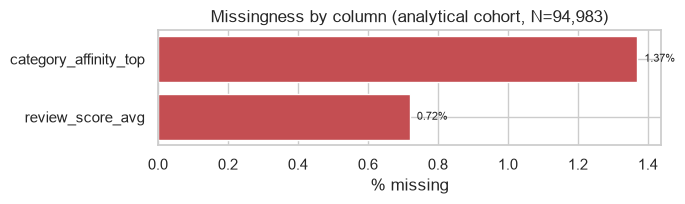

In [3]:
missing = eda.missingness_report(df)
fig = plots.plot_missingness(missing)
plots.save_fig(fig, "01_missingness.png")
missing[missing["n_missing"] > 0]


## 3. Outliers (observed)

IQR-fence (k=1.5) flags on the revenue columns. Outliers here are real
high-value customers — flagged for the record, **not removed** (they carry
information about the spend distribution and will be confounders, not noise).


,column,q1,q3,iqr,lower_fence,upper_fence,n_outliers,pct_outliers
0,total_revenue,63.10,182.93,119.83,-116.65,362.68,7565,7.96
1,avg_order_value,62.41,176.97,114.56,-109.42,348.80,7496,7.89


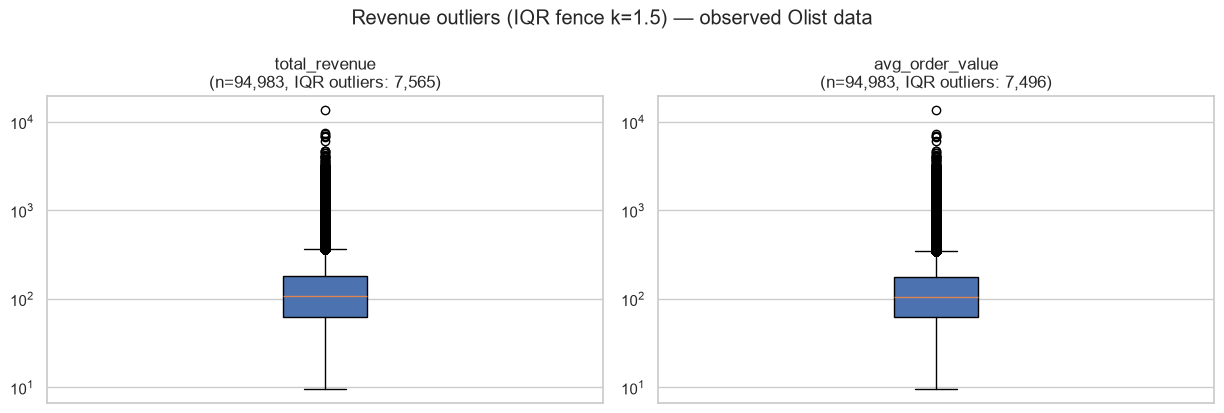

In [4]:
flags = eda.iqr_outlier_flags(df)
out_sum = eda.outlier_summary(df, flags)
fig = plots.plot_outlier_box(df, eda.REVENUE_COLS, log=True)
plots.save_fig(fig, "02_outliers_revenue.png")
out_sum


## 4. Distributions (observed)

Olist reality check: revenue/total spend is right-skewed (median R$108 vs a
long tail to R$13k), ~97% of customers are one-time buyers, tenure and
recency are spread across the full 2016-09 → 2018-09 window.


,column,n,mean,std,min,q25,median,q75,max,skew,kurtosis
0,tenure_days,94983,246.00,153.48,5.00,122.00,227.00,356.00,729.00,0.43,-0.68
1,recency_days,94983,243.33,152.98,0.00,119.00,224.00,352.00,729.00,0.45,-0.66
2,order_count,94983,1.03,0.21,1.00,1.00,1.00,1.00,16.00,11.51,373.53
3,total_revenue,94983,165.67,226.73,9.59,63.10,107.90,182.93,13664.08,9.11,232.15
4,avg_order_value,94983,160.73,219.89,9.59,62.41,105.74,176.96,13664.08,9.31,246.51
5,review_score_avg,94299,4.11,1.32,1.00,4.00,5.00,5.00,5.00,-1.41,0.70
6,review_count,94983,1.03,0.27,0.00,1.00,1.00,1.00,16.00,8.54,189.24


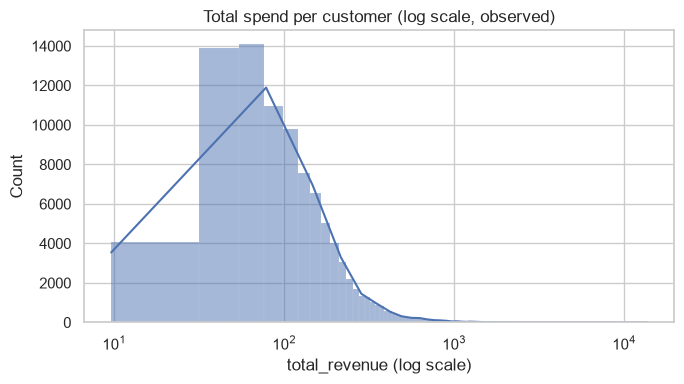

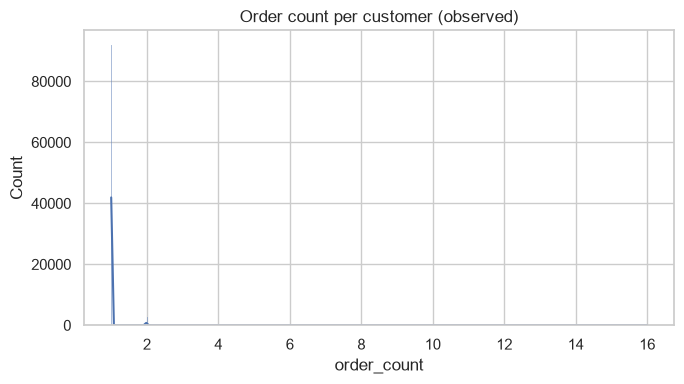

In [5]:
dist = eda.distribution_summary(df, eda.NUMERIC_COLS)
fig = plots.plot_hist(df, "total_revenue", log_x=True, title="Total spend per customer (log scale, observed)")
plots.save_fig(fig, "03_revenue_log_hist.png")
fig = plots.plot_hist(df, "order_count", title="Order count per customer (observed)")
plots.save_fig(fig, "04_order_count_hist.png")
dist


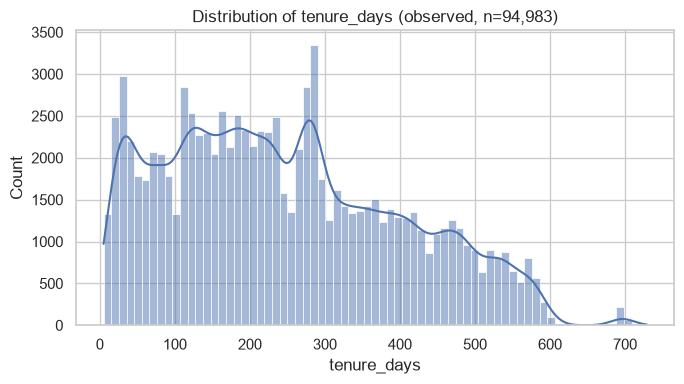

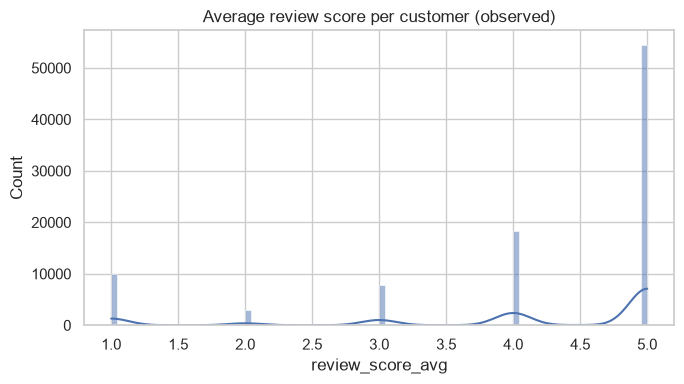

In [6]:
fig = plots.plot_hist(df, "tenure_days")
plots.save_fig(fig, "05_tenure_hist.png")
fig = plots.plot_hist(df, "review_score_avg", title="Average review score per customer (observed)")
plots.save_fig(fig, "06_review_score_hist.png")
plt.show()


### 4.1 Geography & category mix (observed)

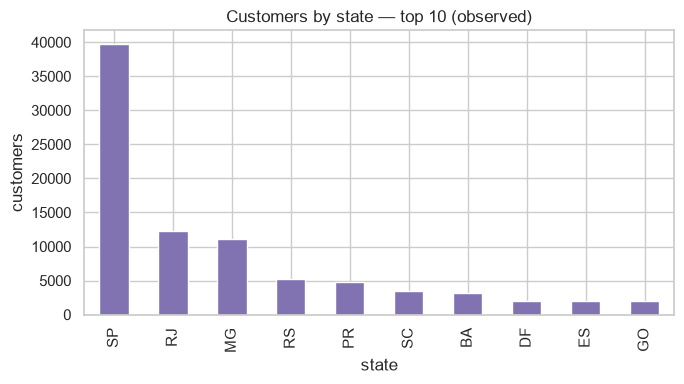

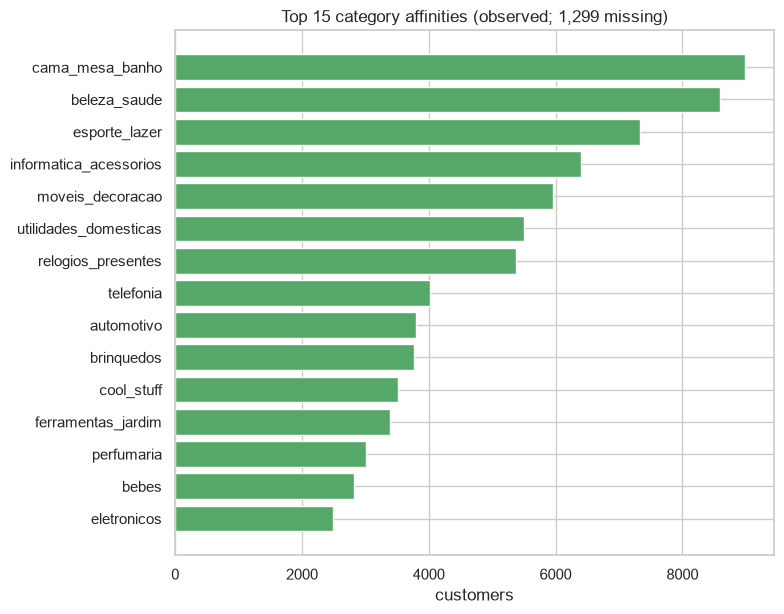

In [7]:
fig = plots.plot_state_bar(df)
plots.save_fig(fig, "07_states.png")
fig = plots.plot_top_categories(df, top_n=15)
plots.save_fig(fig, "08_categories.png")
plt.show()


## 5. Monthly activity / seasonality (observed)

Orders and revenue by purchase month — used for seasonal controls and the
simulation's campaign grid later.


,month,n_customer_months,n_customers,n_orders,revenue
16,2018-02,6468,6468,6624,979486.16
17,2018-03,7077,7077,7168,1152656.99
18,2018-04,6863,6863,6919,1156248.89
19,2018-05,6775,6775,6833,1145686.46
20,2018-06,6106,6106,6145,1020381.90
21,2018-07,6172,6172,6233,1039783.58
22,2018-08,6380,6380,6421,996973.51
23,2018-09,1,1,1,166.46


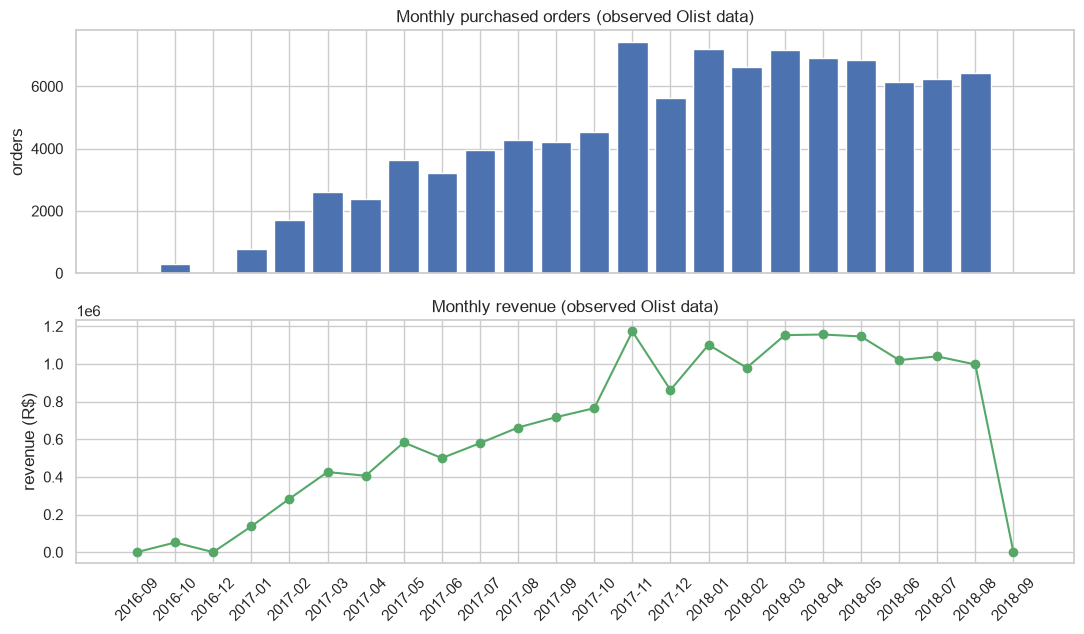

In [8]:
om = cohorts.load_order_monthly()
monthly = cohorts.cohort_summary(om)
fig = plots.plot_monthly_activity(monthly)
plots.save_fig(fig, "09_monthly_activity.png")
monthly.tail(8)


## 6. Acquisition cohorts & retention (observed)

Cohort = calendar month of the customer's **first** purchased order. Retention
is the share of a cohort placing ≥1 further purchased order in months m+0…m+12.
The steep drop-off confirms the documented reality: Olist is structurally a
**one-transaction marketplace** (~97% single-purchase customers), so retention
is a sparse signal — `order_count` and `recency` will dominate RFM-style
features and must be handled with care in the causal design.


acquisition months: 2016-09 .. 2018-08 (n=23)


,cohort_month,m+0,m+1,m+2,m+3,m+4,m+5,m+6,m+7,m+8,m+9,m+10,m+11,m+12
0,2016-09,100.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,2016-10,100.0,0.00,0.00,0.00,0.00,0.00,0.35,0.00,0.00,0.35,0.00,0.35,0.00
2,2016-12,100.0,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,2017-01,100.0,0.40,0.27,0.13,0.40,0.13,0.40,0.13,0.13,0.00,0.40,0.13,0.66
4,2017-02,100.0,0.24,0.30,0.12,0.41,0.12,0.24,0.18,0.12,0.18,0.12,0.30,0.12
5,2017-03,100.0,0.51,0.35,0.39,0.35,0.16,0.16,0.31,0.35,0.08,0.39,0.12,0.23


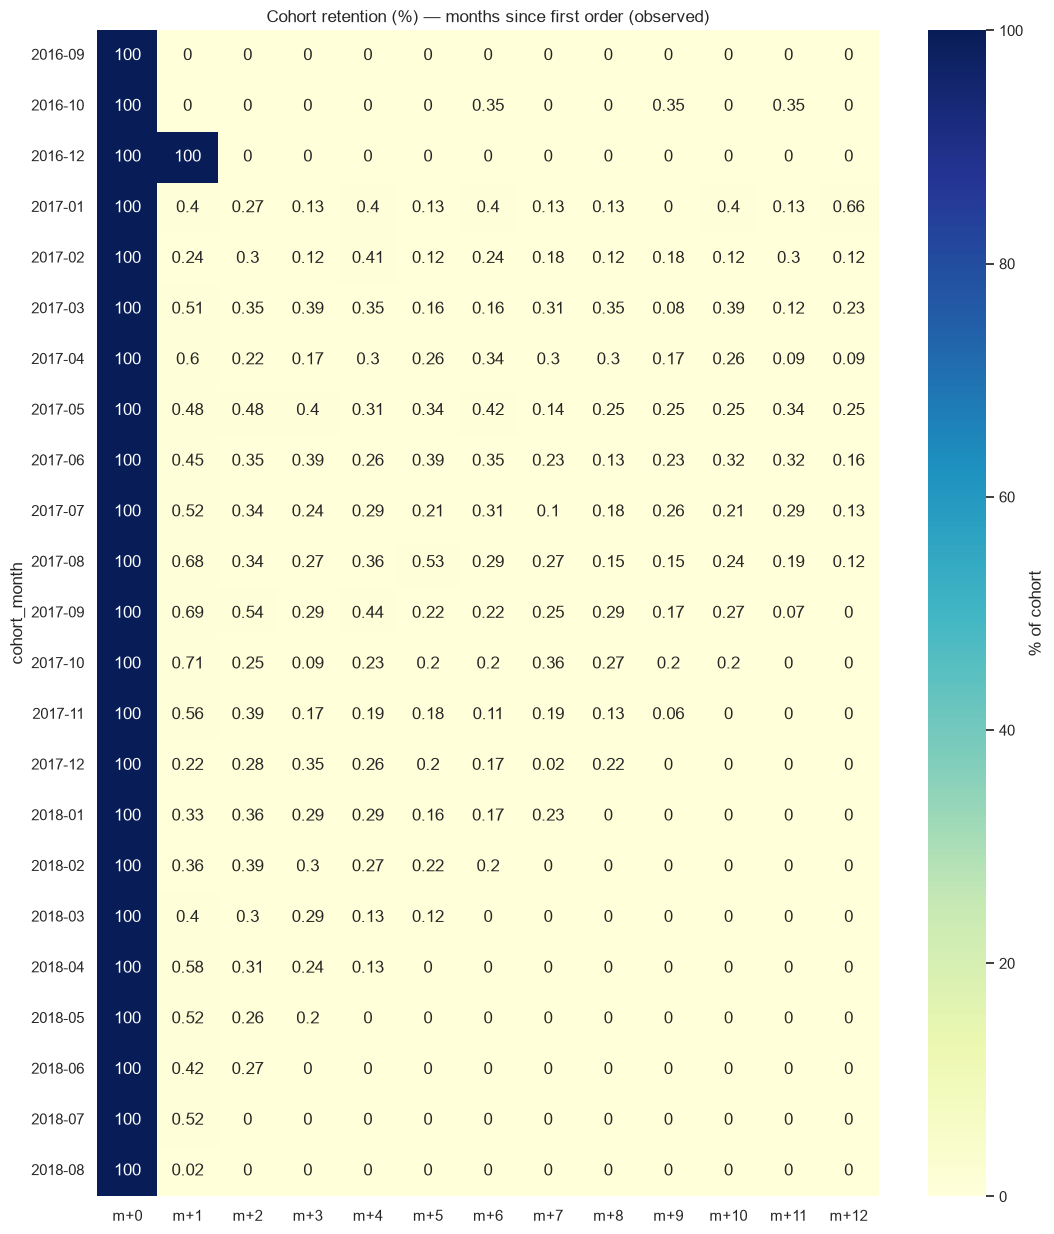

In [9]:
acq = cohorts.acquisition_cohorts(om)
print(f"acquisition months: {acq['cohort_month'].min()} .. {acq['cohort_month'].max()} (n={len(acq)})")
ret = cohorts.retention_matrix(om, max_months=12)
fig = plots.plot_retention_heatmap(ret)
plots.save_fig(fig, "10_retention_heatmap.png")
ret.head(6)


In [10]:
# overall m+1..m+12 retention (mean across cohorts with full history)
full = ret.set_index("cohort_month")[["m+1", "m+3", "m+6", "m+12"]].mean().round(2)
print("mean retention across cohorts with full history:")
print(full.to_string())


mean retention across cohorts with full history:
m+1     4.75
m+3     0.19
m+6     0.17
m+12    0.08


## 7. RFM segmentation (observed)

Scores: **R** = recency quintiles (5 = most recent), **F** = frequency bands
(1 / 2 / 3-4 / 5-9 / 10+ — quantiles would collapse because P(F=1)≈0.97),
**M** = monetary quintiles. Composite `rfm_score = 100R + 10F + M`.

This is a *descriptive* segmentation of observed data; on Days 4-5 it feeds
the confounder audit and the DAG.


,rfm_segment,n_customers,total_revenue,avg_revenue,avg_order_count,avg_recency_days,share_pct
0,one_time_lapsed,36867,5982974.78,162.29,1.00,401.02,38.81
1,new_customer,30302,2955850.72,97.55,1.02,95.37,31.90
2,lapsed,16126,1739979.01,107.90,1.07,236.00,16.98
3,big_spender,11260,4930680.78,437.89,1.08,137.99,11.85
4,at_risk,262,37401.36,142.75,2.00,223.37,0.28
5,loyal,152,77378.91,509.07,3.24,125.51,0.16
6,champions,14,11261.47,804.39,6.29,99.50,0.01


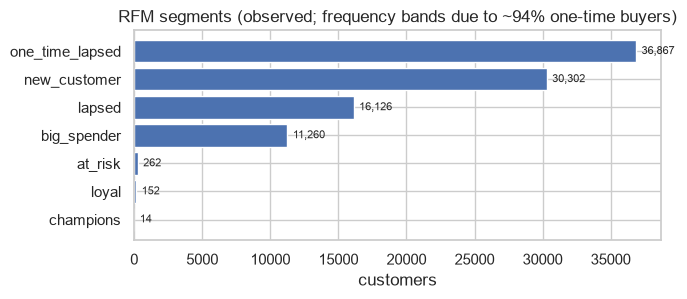

In [11]:
df_rfm = rfm.add_rfm(df)
seg = rfm.segment_summary(df_rfm)
fig = plots.plot_rfm_segments(seg)
plots.save_fig(fig, "11_rfm_segments.png")
seg


## 8. Channel descriptive statistics — ⚠️ **SIMULATED PREVIEW**

Olist has **no marketing data** (no campaigns, impressions, spend — see
`docs/data-feasibility.md`). The row below is NOT observed. It is a clearly
labelled preview of the synthetic marketing layer (`sim_*`) that Days 5+
will use to benchmark estimators against known ground truth.

Preview design (config-driven, seed-fixed): latent purchase intent `sim_u`
drives both exposure and conversion (confounding by design); exposures are
drawn from logistic targeting rules; a 14-day conversion outcome and
follow-on revenue are simulated.


In [12]:
# deterministic: RNG seed fixed by config "seed"
sim = build_sim_preview()
print(f"sim preview: {len(sim):,} rows x {sim.shape[1]} cols | sim_* columns:")
print([c for c in sim.columns if c.startswith("sim_")])


sim preview: 94,983 rows x 27 cols | sim_* columns:
['sim_u', 'sim_p_email', 'sim_exposed_email', 'sim_p_social', 'sim_exposed_social', 'sim_p_search', 'sim_exposed_search', 'sim_p_display', 'sim_exposed_display', 'sim_ground_truth_email', 'sim_ground_truth_social', 'sim_ground_truth_search', 'sim_ground_truth_display', 'sim_converted_14d', 'sim_revenue_14d']


,channel,pct_exposed,n_exposed
0,email,29.88,28380
1,social,26.01,24707
2,search,33.35,31678
3,display,37.34,35470


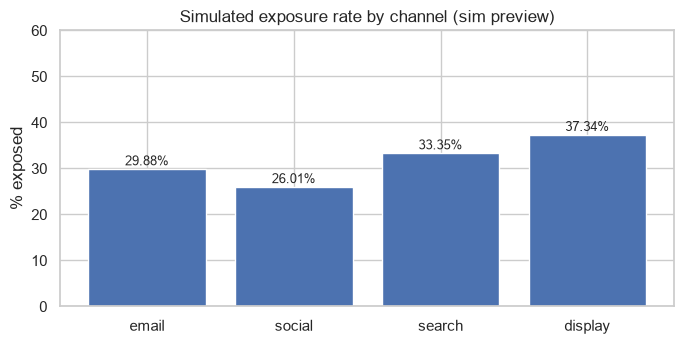

In [13]:
chan = channel_descriptive_stats(sim)
fig = plots.plot_channel_exposure(chan["exposure_rate"])
plots.save_fig(fig, "12_sim_exposure_rates.png")
chan["exposure_rate"]


,channel,conv_exposed_pct,conv_unexposed_pct,conv_diff_pp
0,email,30.44,17.91,12.52
1,social,30.00,18.72,11.27
2,search,30.17,17.40,12.77
3,display,28.66,17.48,11.17


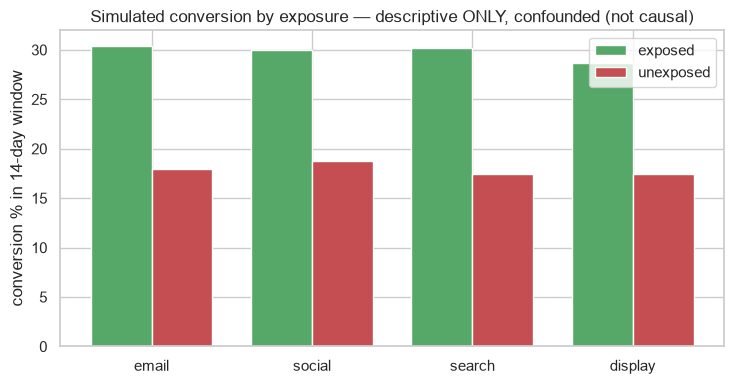

In [14]:
fig = plots.plot_naive_conversion(chan["naive_conversion"])
plots.save_fig(fig, "13_sim_naive_conversion.png")
chan["naive_conversion"]


### Interpreting the sim preview (read carefully)

* Exposure rates differ **by channel by design** (targeting rules differ).
* The «conversion among exposed vs unexposed» gap is a **naive descriptive
  difference** — it is NOT a causal effect and will NOT match the embedded
  ground truth, precisely because `sim_u` (latent intent) and the real
  features confound assignment. Day 8 will quantify this raw gap, and
  Days 9-12 will show adjusted estimators recovering the embedded effects.
* Ground-truth log-odds per channel are stored in `sim_ground_truth_*`.

| Channel | Embedded effect (log-odds) | Narrative |
|---|---|---|
| Email | +0.12 | reactivation works |
| Search | +0.15 | captures demand |
| Display | 0.00 | apparent effect is pure confounding |
| Social | -0.08 | sleeping dogs |


In [15]:
sim[["sim_ground_truth_email", "sim_ground_truth_search", "sim_ground_truth_display", "sim_ground_truth_social"]].iloc[0].to_frame("effect_log_odds")


,effect_log_odds
sim_ground_truth_email,0.12
sim_ground_truth_search,0.15
sim_ground_truth_display,0.00
sim_ground_truth_social,-0.08


## 9. Summary & next steps

**Observed facts locked in (sane distributions ✅):** 94,983-customer cohort via
98,199 purchased orders for a ~96k-customer / ~100k-order raw dataset; missingness
only in review/category proxies; revenue right-skewed with a long high-value tail;
~97% one-time buyers (sparse frequency, low retention — will shape the confounder
audit and RFM use); SP-dominant geography; monthly order/revenue seasonality;
RFM segments led by `one_time_lapsed`, `new_customer`, `big_spender`.

**Next (Days 4-5):** confounder audit → causal DAG → adjustment set, then
propensity scoring (Day 6) and matching (Day 7) on the simulated preview.

**Gate 1:** after Day 7, STOP for human validation before Week 2.
